Importing libraries, loading the dataset, mounting it from google drive(as I uploaded it there)

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/Hospital Readmission/Dataset/diabetic_data.csv"

df = pd.read_csv(path, keep_default_na=False, na_values=['?'])

/tmp/ipykernel_14921/2520090773.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, keep_default_na=False, na_values=['?'])


Displaying the dataset

In [ ]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 101766
Columns : 50


In [ ]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [ ]:
df.dtypes

,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


Checking for Missing Values

In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
missing = df.isnull().sum()

missing_percentage = (missing/len(df))*100

pd.DataFrame({
    "Missing Values":missing,
    "Percentage":missing_percentage
}).sort_values(by="Percentage",ascending=False)

,Missing Values,Percentage
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
admission_type_id,0,0.000000
patient_nbr,0,0.000000
encounter_id,0,0.000000


Check for duplicates

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Repeat patients (same patient_nbr, multiple visits):", df['patient_nbr'].duplicated().sum())

Duplicate rows: 0
Repeat patients (same patient_nbr, multiple visits): 30248


In [ ]:
df.drop_duplicates(inplace=True)

Exploratory Data Analysis (EDA)

In [ ]:
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


Visualization - graphs

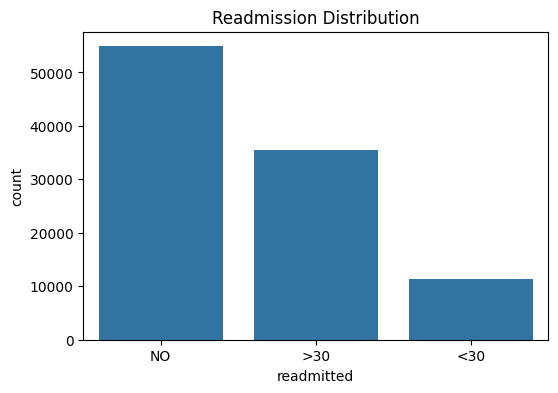

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

In [ ]:
y.value_counts(normalize=True)

,proportion
readmitted,
0,0.5369
1,0.4631


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


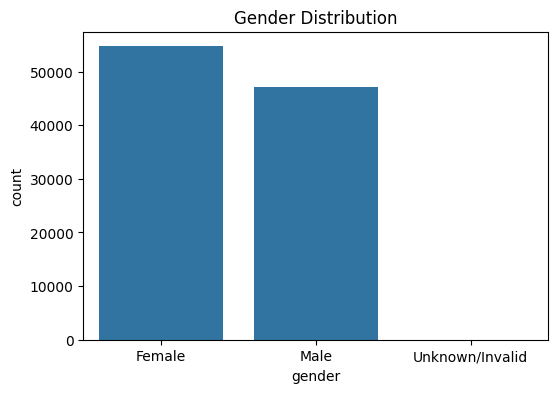

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

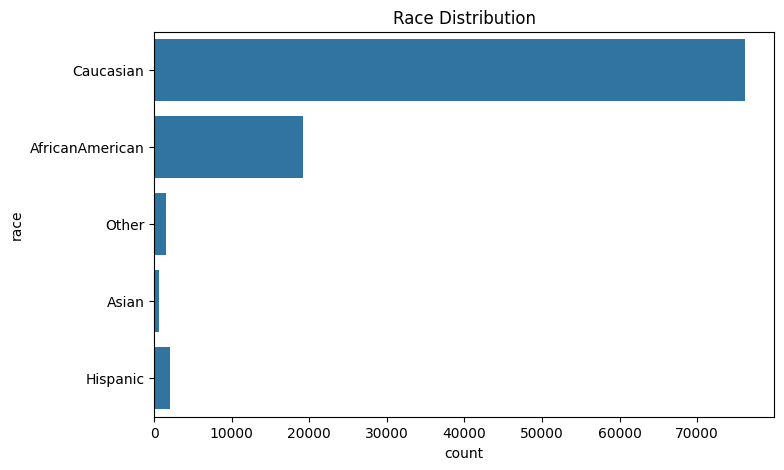

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='race', data=df)
plt.title("Race Distribution")
plt.show()

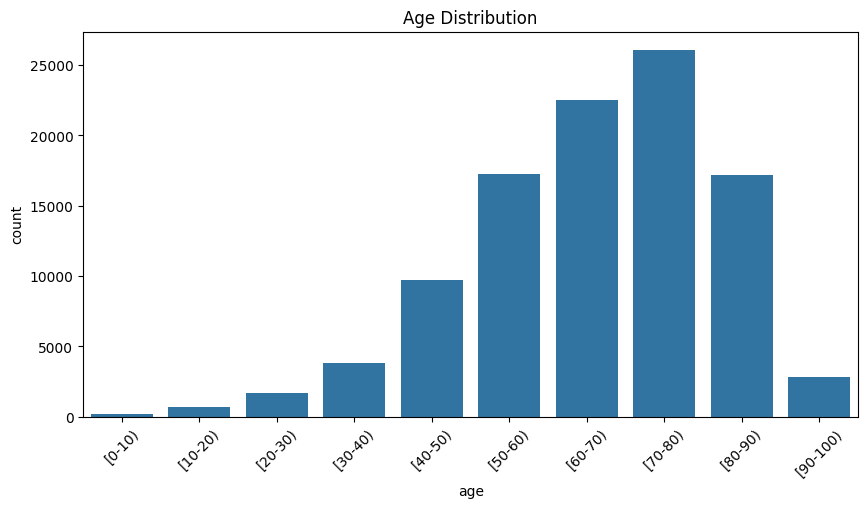

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

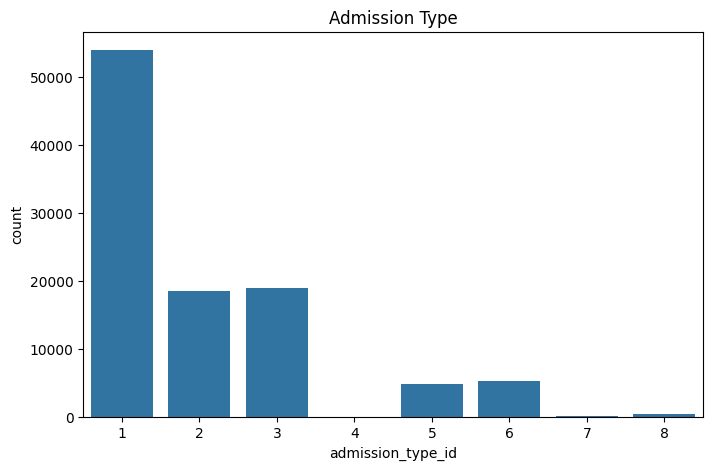

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='admission_type_id', data=df)
plt.title("Admission Type")
plt.show()

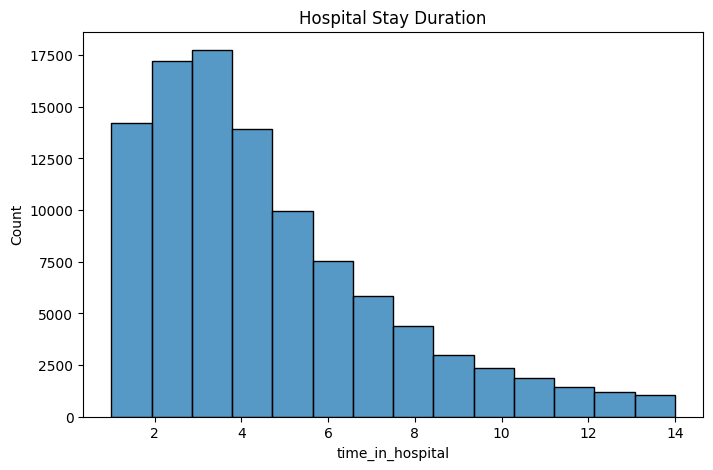

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['time_in_hospital'], bins=14)
plt.title("Hospital Stay Duration")
plt.show()

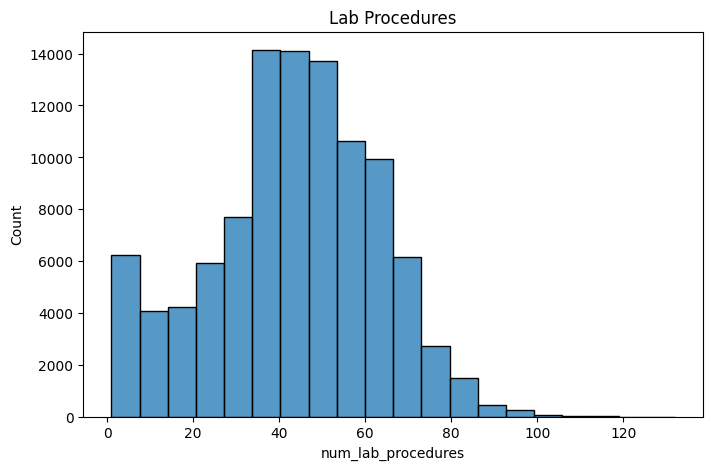

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['num_lab_procedures'], bins=20)
plt.title("Lab Procedures")
plt.show()

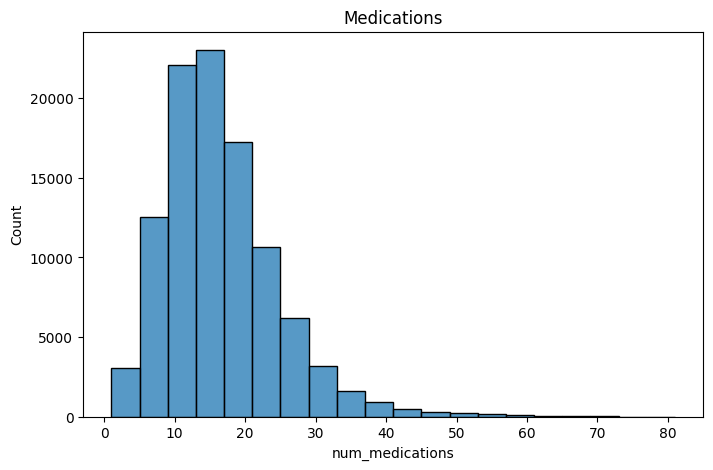

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['num_medications'], bins=20)
plt.title("Medications")
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

Correlation Heatmap

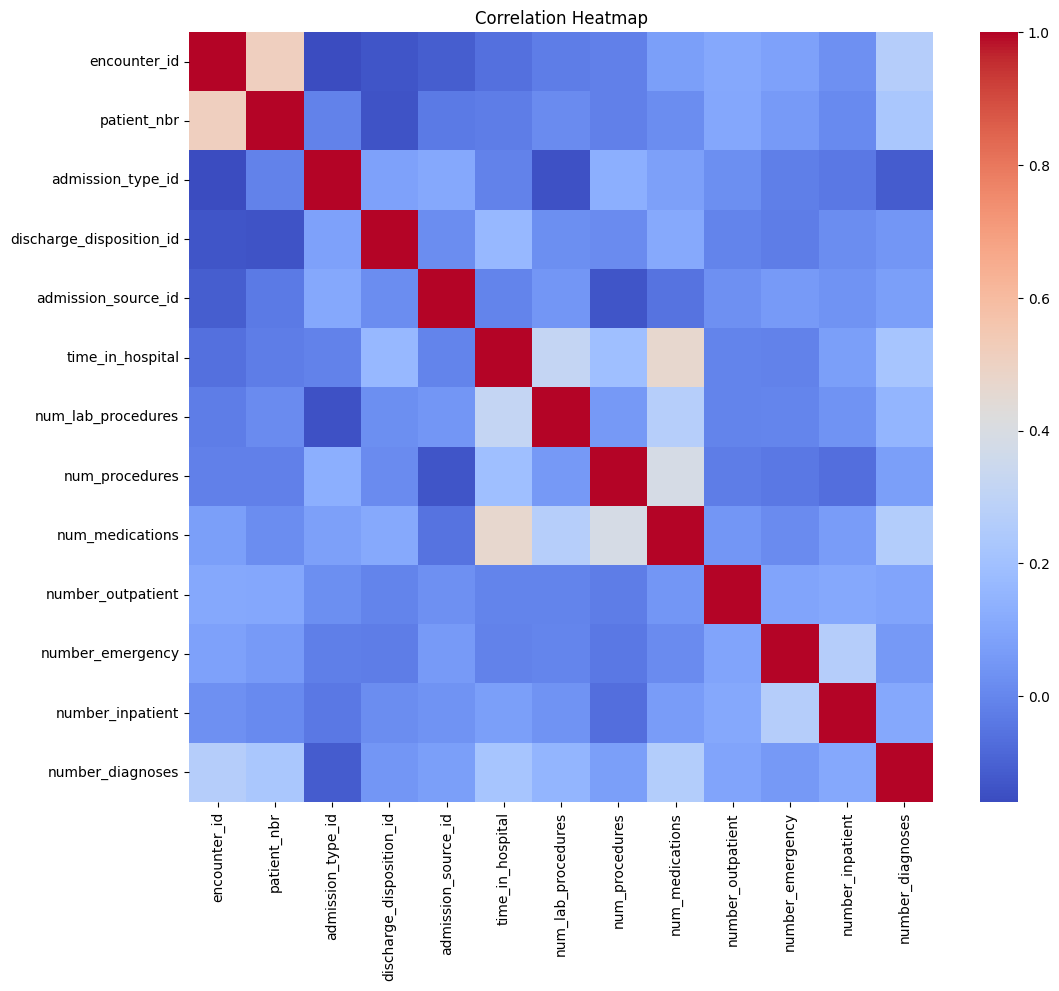

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Cleaning & Dropping

Dropped few columns because they had lot of missing values

In [ ]:
patient_ids = df['patient_nbr'].copy()

df.drop(columns=['weight', 'payer_code', 'medical_specialty',
                  'encounter_id', 'patient_nbr'], inplace=True)

In [ ]:
df.fillna({'race': df['race'].mode()[0]}, inplace=True)

print(df[['diag_1','diag_2','diag_3']].isnull().sum())
print("Total rows before dropping:", len(df))

df.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)

diag_1      21
diag_2     358
diag_3    1423
dtype: int64
Total rows before dropping: 101766


In [ ]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


Checking if any missing values present after cleaning (re-checking)

In [ ]:
df.isnull().sum()

,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


Label-encoding

In [ ]:
df['readmitted'] = df['readmitted'].map({'NO': 0, '<30': 1, '>30': 1})

In [ ]:
from sklearn.preprocessing import LabelEncoder

high_cardinality = ['diag_1', 'diag_2', 'diag_3']
for col in high_cardinality:
    df[col] = LabelEncoder().fit_transform(df[col])

other_categorical = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=other_categorical, drop_first=True)

Train-test data splitting (80-20)

In [ ]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [ ]:
print("Scaler was fit on:", scaler.n_samples_seen_, "samples")
print("X_train size:", X_train.shape[0])
print("Full dataset size:", len(df))

Scaler was fit on: 80195 samples
X_train size: 80195
Full dataset size: 100244


Saving the pre-processed dataset & Visualization graphs

In [ ]:
from pathlib import Path

output_dir = Path('/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset')
output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
train_final = X_train_scaled.copy()
train_final['readmitted'] = y_train.values

test_final = X_test_scaled.copy()
test_final['readmitted'] = y_test.values

train_final.to_csv(output_dir / "train_processed.csv", index=False)
test_final.to_csv(output_dir / "test_processed.csv", index=False)

In [ ]:
import os

print("Folder exists:", os.path.exists(output_dir))
print("Contents:", os.listdir(output_dir))

Folder exists: True
Contents: ['train_processed.csv', 'test_processed.csv', 'dataset_summary.csv', 'numeric_summary_stats.csv', 'target_class_balance.csv', 'readmission_distribution.png', 'age_distribution.png', 'correlation_heatmap.png']


In [ ]:
# Basic dataset summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique()
})
summary.to_csv(f"{output_dir}/dataset_summary.csv")

df.describe().T.to_csv(f"{output_dir}/numeric_summary_stats.csv")

y.value_counts(normalize=True).to_csv(f"{output_dir}/target_class_balance.csv")

print("Summary files saved.")

Summary files saved.


In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=pd.DataFrame({'readmitted': y}))
plt.title("Readmission Class Distribution")
plt.savefig(f"{output_dir}/readmission_distribution.png", dpi=200, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10,5))
sns.countplot(x='age', data=pd.read_csv("/content/drive/MyDrive/Hospital Readmission/Dataset/diabetic_data.csv", keep_default_na=False, na_values=['?']))
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.savefig(f"{output_dir}/age_distribution.png", dpi=200, bbox_inches='tight')
plt.close()

plt.figure(figsize=(12,10))
sns.heatmap(X_train_scaled.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Post-Processing)")
plt.savefig(f"{output_dir}/correlation_heatmap.png", dpi=200, bbox_inches='tight')
plt.close()

print("Graphs saved as PNGs.")

/tmp/ipykernel_14921/979143402.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  sns.countplot(x='age', data=pd.read_csv("/content/drive/MyDrive/Hospital Readadmission/Dataset/diabetic_data.csv", keep_default_na=False, na_values=['?']))


Graphs saved as PNGs.
